# Prédiction du départ des clients

Layla EL GOZMIR · Projet portfolio

Ce notebook commente les résultats du pipeline. Le code d'analyse versionné reste la source de vérité.
Les résultats fournis sont issus d'une exécution réelle, et non de valeurs saisies manuellement.
Exécuter toutes les cellules ; mettre `REBUILD=True` pour recalculer (Internet requis au premier lancement).


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
REBUILD = False


In [2]:
from train import run
if REBUILD or not (ROOT / 'reports/metrics.json').exists():
    result = run()
else:
    result = json.loads((ROOT / 'reports/metrics.json').read_text(encoding='utf-8'))
display(Markdown((ROOT / 'reports/synthese.md').read_text(encoding='utf-8')))


# Évaluation exécutée

7043 clients ; churn observé : 26.5%.
Séparation stratifiée 60/20/20 : 4225/1409/1409.
Modèle choisi sur validation : **logistique**, seuil **0.07**.
Sur test : précision 0.383, rappel 0.971, F1 0.549, average precision 0.629.
Lift du premier quintile sur test : 2.50.

Les coûts FP=10 et FN=100 sont des hypothèses illustratives, pas des coûts mesurés.
Le coût de classement ne modélise ni l'efficacité d'une remise ni le gain causal d'une campagne.
`targeting_test.csv` est une simulation rétrospective sur clients déjà étiquetés, pas une liste de vrais clients à contacter.
L'importance par permutation est calculée sur validation ; elle mesure une dépendance prédictive, pas une cause du départ.
L'historique ne contient pas de dates de photographie permettant de valider une anticipation temporelle.
Avant usage réel : définir une date de score, un horizon, vérifier la disponibilité des variables, contrôler les écarts par groupe et tester une campagne randomisée.


## Sélection sans fuite

Prétraitement dans chaque pli d'entraînement. Modèle et seuil choisis sur validation seulement.
Les coûts sont illustratifs ; les résultats test n'interviennent pas dans le choix.


In [3]:
display(result['split_sizes'])
display(pd.DataFrame(result['comparison_validation']))
display(pd.DataFrame(result['test_at_0_5']).T)

{'train': 4225, 'validation': 1409, 'test': 1409}

,model,cv_average_precision,validation_average_precision,params,fit_seconds
0,reference,0.265325,0.265436,{},0.425447
1,logistique,0.668761,0.643369,{'model__C': 10},1.396785
2,arbre,0.617821,0.607678,"{'model__max_depth': 8, 'model__min_samples_le...",2.136441


,precision,recall,f1,average_precision,roc_auc,confusion_matrix
reference,0.0,0.0,0.0,0.265436,0.5,"[[1035, 0], [374, 0]]"
logistique,0.645963,0.55615,0.597701,0.628969,0.841998,"[[921, 114], [166, 208]]"
arbre,0.630137,0.491979,0.552553,0.605742,0.825304,"[[927, 108], [190, 184]]"


{'precision': 0.3829113924050633,
 'recall': 0.9705882352941176,
 'f1': 0.5491679273827534,
 'average_precision': 0.6289693402473355,
 'roc_auc': 0.8419979849647368,
 'confusion_matrix': [[450, 585], [11, 363]]}

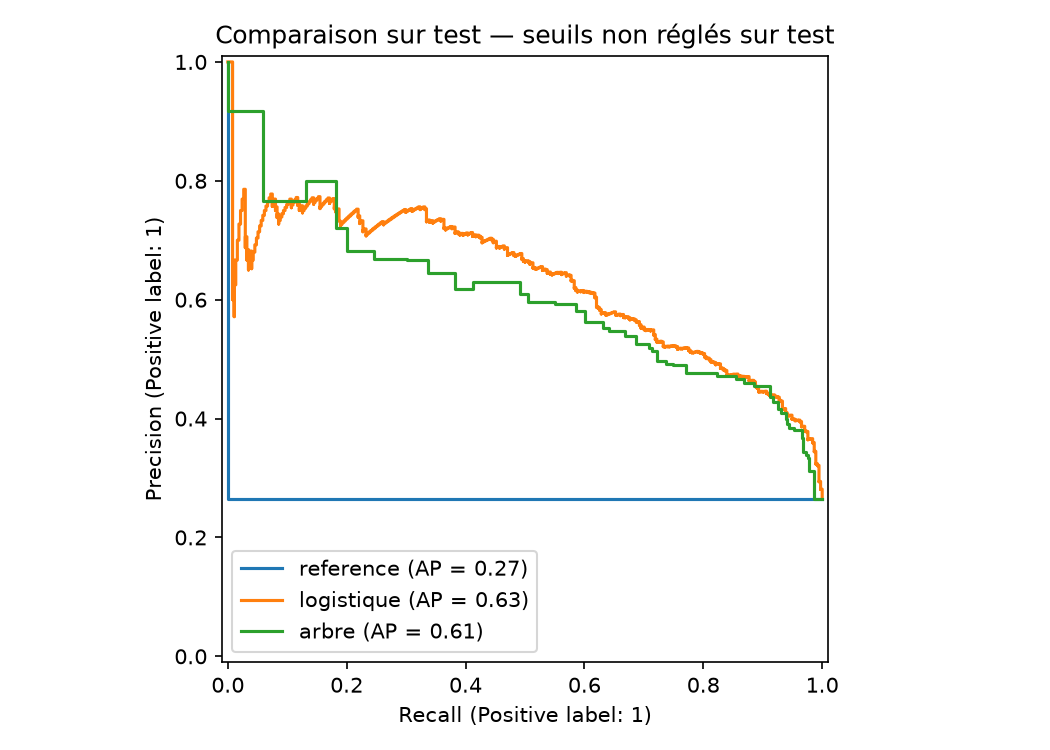

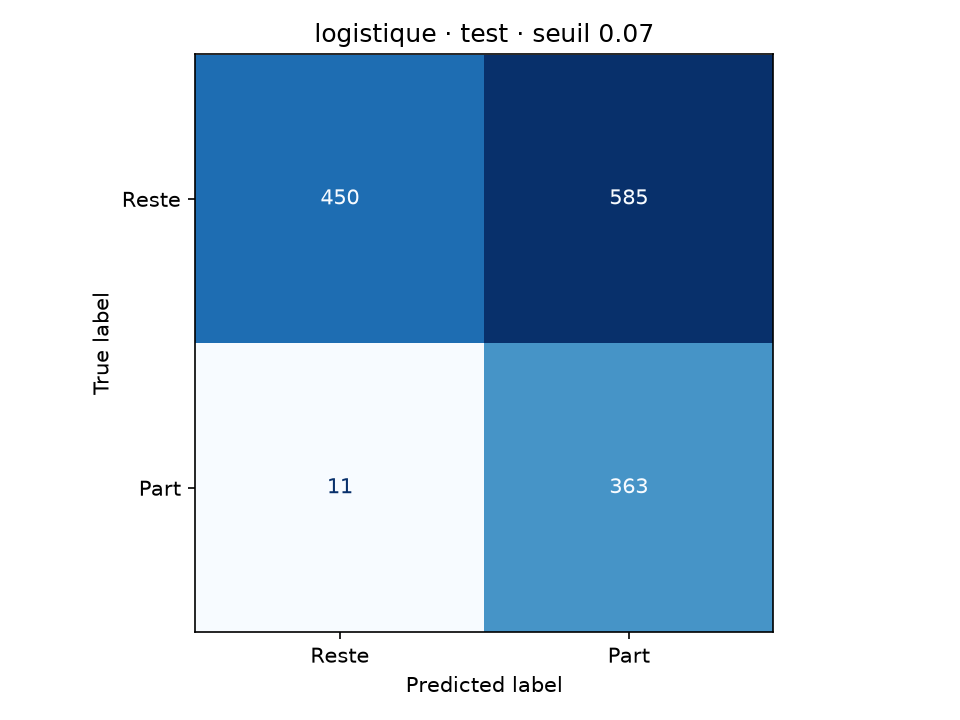

In [4]:
display(result['selected_test'])
display(Image(filename=str(ROOT / 'reports/precision_recall.png')))
display(Image(filename=str(ROOT / 'reports/confusion.png')))

## Coûts et interprétation

Un seuil faible peut accroître le rappel tout en augmentant fortement les faux positifs.
L'importance mesure une dépendance du score, pas une causalité.


In [5]:
display(pd.read_csv(ROOT / 'reports/threshold_validation.csv').sort_values('cost').head())
display(pd.read_csv(ROOT / 'reports/importance_validation.csv').head(10))

,threshold,fp,fn,cost,contact_rate
7,0.07,600,14,7400.0,0.681334
6,0.06,626,12,7460.0,0.701207
4,0.04,690,8,7700.0,0.749468
5,0.05,659,12,7790.0,0.724627
8,0.08,578,22,7980.0,0.660043


,feature,mean_ap_loss,std
0,tenure,0.249250,0.006449
1,InternetService,0.207138,0.013846
2,MonthlyCharges,0.124060,0.013494
3,Contract,0.062240,0.007307
4,StreamingMovies,0.057671,0.010824
5,TotalCharges,0.044417,0.010514
6,StreamingTV,0.040106,0.009790
7,MultipleLines,0.026745,0.006245
8,OnlineSecurity,0.017231,0.008084
9,TechSupport,0.015698,0.006575


In [6]:
parts=pd.read_csv(ROOT / 'reports/partitions.csv')
assert not parts.customer_id.duplicated().any()
display(parts.partition.value_counts())

partition
train         4225
test          1409
validation    1409
Name: count, dtype: int64

## À expliquer en entretien

1. Quelle est l'unité d'observation et comment les doublons sont-ils traités ?
2. Quelles informations servent à sélectionner les paramètres et lesquelles servent à évaluer ?
3. Quelle décision métier est envisageable, et quelles limites empêchent une conclusion plus forte ?

Voir le README pour les sources, les limites, les commandes et l'attribution de l'assistance IA.
